In [4]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib import cm as cm
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import explained_variance_score, median_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split, cross_validate
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet, RANSACRegressor, SGDRegressor, HuberRegressor, BayesianRidge # Linear models
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor, ExtraTreesRegressor  # Ensemble methods
from xgboost import XGBRegressor, plot_importance 
from sklearn.svm import SVR, SVC, LinearSVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA, PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import learning_curve, validation_curve, GridSearchCV
from sklearn.base import clone
from sklearn.metrics import mean_squared_error as MSE
warnings.filterwarnings("ignore")
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
plt.style.use('seaborn-white')

In [5]:
df = pd.read_csv("../data/data_energy.csv")

In [6]:
df

,at,v,ap,rh,pe
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [7]:
target = "pe"
control_variables = ["at", "v"]
features = list(df.columns)
features.remove(target)


print("features /  Action Space: ", features)
print("control_variables: ", control_variables)
print("target: ", target)

target = target 
action_space = control_variables
observation_space = features


features /  Action Space:  ['at', 'v', 'ap', 'rh']
control_variables:  ['at', 'v']
target:  pe


In [11]:
def get_bounds(df, bins=100):
    """
    Plot histogram of column called "col"
    Args:
        df: pd.DataFrame that we need to analyse
        col: string, col nome
    Returns:
        Histogram plot
    """
    print("Shape inicial:", df.shape)
    bounds = []
    for col in df.columns:
        iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
        if iqr == 0:
            iqr = 1 
            
        q1 = df[col].quantile(0.25) - 1.5 * iqr
        q3 = df[col].quantile(0.75) + 1.5 * iqr
        plt.figure(figsize=(10, 6))
        plt.hist(df[col], bins=bins, alpha=0.5)
        plt.axvline(df[col].quantile(0.0), ls="-.", color="b")
        plt.axvline(df[col].quantile(1.0), ls="-.", color="b")
        plt.axvline(df[col].quantile(0.5), ls="-.", color="#000000")
        plt.axvline(q1, ls="-.", color="r")
        plt.axvline(q3, ls="-.", color="r")
        plt.title("Histogram: " + col)
        plt.xlabel(col)
        plt.ylabel("Frecuency")
        plt.show()
        print("Median (Q2):", df[col].median())
        print("Q3 - Q4:", df[col].quantile(1.0) - df[col].quantile(0.75))
        print("Q0 - Q1:", df[col].quantile(0.25) - df[col].quantile(0.0))
        print("IQR:", df[col].quantile(0.25) - 1.5 * iqr)
        print("Q1 - 1.5*IQR:", q1)
        print("Q3 + 1.5*IQR:", q3)
        bounds.append([col, max(df[col].min(), q1), min(q3, df[col].max())])

    bounds = pd.DataFrame(bounds, columns=["variable", "lower_lim", "upper_lim"])
    return bounds

Shape inicial: (9568, 5)


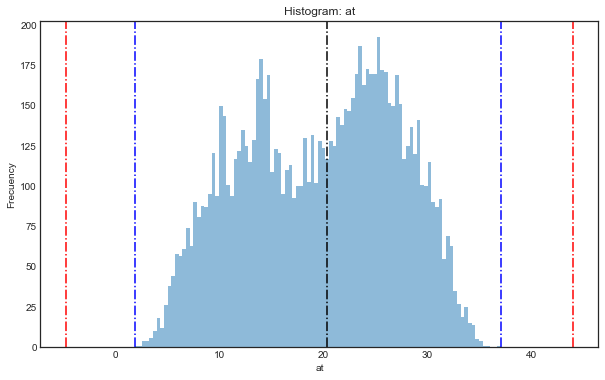

Median (Q2): 20.345
Q3 - Q4: 11.39
Q0 - Q1: 11.7
IQR: -4.804999999999998
Q1 - 1.5*IQR: -4.804999999999998
Q3 + 1.5*IQR: 44.035


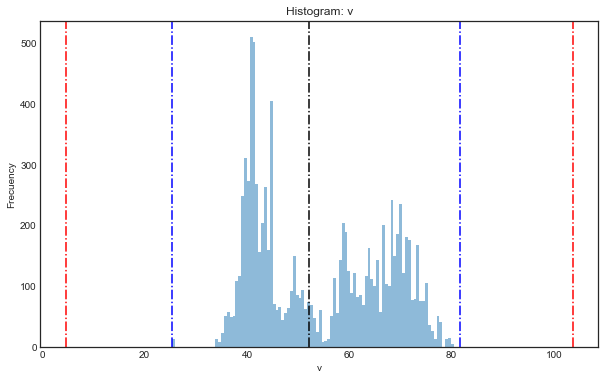

Median (Q2): 52.08
Q3 - Q4: 15.019999999999996
Q0 - Q1: 16.380000000000003
IQR: 4.539999999999999
Q1 - 1.5*IQR: 4.539999999999999
Q3 + 1.5*IQR: 103.74000000000001


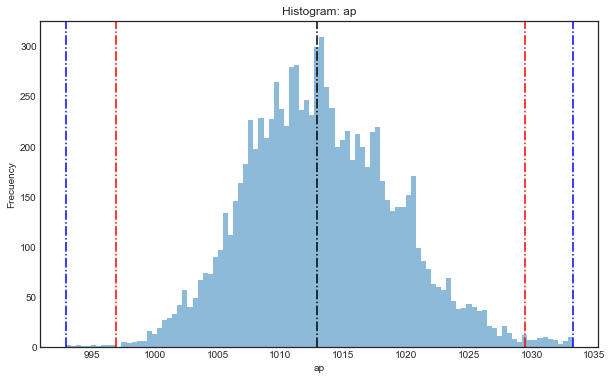

Median (Q2): 1012.94
Q3 - Q4: 16.039999999999964
Q0 - Q1: 16.210000000000036
IQR: 996.8600000000001
Q1 - 1.5*IQR: 996.8600000000001
Q3 + 1.5*IQR: 1029.5


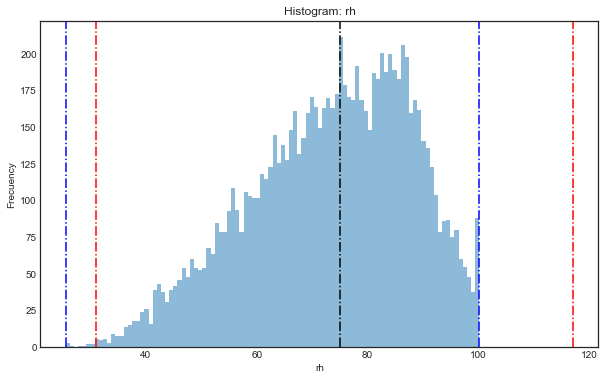

Median (Q2): 74.975
Q3 - Q4: 15.329999999999998
Q0 - Q1: 37.7675
IQR: 31.073750000000004
Q1 - 1.5*IQR: 31.073750000000004
Q3 + 1.5*IQR: 117.08375


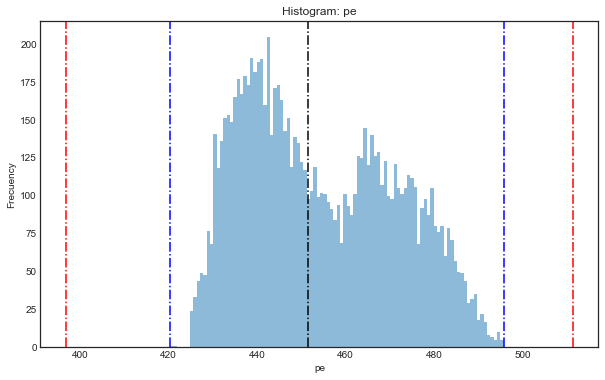

Median (Q2): 451.54999999999995
Q3 - Q4: 27.329999999999984
Q0 - Q1: 19.49000000000001
IQR: 396.73
Q1 - 1.5*IQR: 396.73
Q3 + 1.5*IQR: 511.45000000000005


In [12]:
bounds = get_bounds(df)

In [13]:
bounds

,variable,lower_lim,upper_lim
0,at,1.81000,37.11
1,v,25.36000,81.56
2,ap,996.86000,1029.50
3,rh,31.07375,100.16
4,pe,420.26000,495.76


In [ ]:
bounds.to_csv("data/bounds.csv")